<a href="https://colab.research.google.com/github/hzhou3031-wq/vit-cnn-flower-classification/blob/main/Flowers_RQ1_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flowers — ViT vs CNN (Oxford 102) — clean rebuild
**Run order:** GPU on (Runtime ▸ Change runtime type ▸ T4), then run cells top to bottom.

Key fix vs before: we let **KerasHub do all preprocessing** (resize + normalisation) and feed it raw images. We first run a **2-epoch sanity check** — both models must beat random (>1%) before the full run.
If any cell errors, copy the full red message and send it back.


In [ ]:
# Cell 1 — Setup
!pip -q install -U keras-hub keras scikit-learn matplotlib
import os, numpy as np, tensorflow as tf, keras, keras_hub
import matplotlib.pyplot as plt
import gc
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
keras.utils.set_random_seed(42)
print("TF:", tf.__version__, "| Keras:", keras.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 88.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.29.1 which is incompatible.
TF: 2.20.0 | Keras: 3.14.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Cell 2 — Download Oxford 102 (no tensorflow_datasets) and build RAW pipelines
import scipy.io, tarfile, urllib.request
IMG_SIZE, BATCH, NUM_CLASSES = 224, 16, 102

base = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/"
for fn in ["102flowers.tgz", "imagelabels.mat", "setid.mat"]:
    if not os.path.exists(fn):
        print("downloading", fn); urllib.request.urlretrieve(base + fn, fn)
if not os.path.exists("jpg"):
    print("extracting"); tarfile.open("102flowers.tgz").extractall(".")

labels = scipy.io.loadmat("imagelabels.mat")["labels"][0] - 1   # 0..101
setid  = scipy.io.loadmat("setid.mat")
trainval = np.concatenate([setid["trnid"][0], setid["valid"][0]])
test_ids = setid["tstid"][0]
rng = np.random.default_rng(42); perm = rng.permutation(len(trainval))
cut = int(0.8 * len(trainval))
tr_ids, va_ids = trainval[perm[:cut]], trainval[perm[cut:]]

def decode(i):
    img = tf.io.decode_jpeg(tf.io.read_file(f"jpg/image_{int(i):05d}.jpg"), channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))      # resize only; NO normalisation here
    return tf.cast(img, tf.float32)

def make_ds(ids, training=False):
    paths = tf.constant([f"jpg/image_{int(i):05d}.jpg" for i in ids])
    labs  = tf.constant([int(labels[int(i)-1]) for i in ids])
    ds = tf.data.Dataset.from_tensor_slices((paths, labs))
    def load(p, y):
        img = tf.cast(tf.image.resize(tf.io.decode_jpeg(tf.io.read_file(p), channels=3),
                                      (IMG_SIZE, IMG_SIZE)), tf.float32)
        if training:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 20.0)
        return img, y
    if training:
        ds = ds.shuffle(2000)
    return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds, val_ds, test_ds = make_ds(tr_ids, True), make_ds(va_ids), make_ds(test_ids)
print("Train / Val / Test:", len(tr_ids), len(va_ids), len(test_ids))
for x, y in train_ds.take(1):
    print("image range:", float(tf.reduce_min(x)), "to", float(tf.reduce_max(x)),
          "| labels:", int(tf.reduce_min(y)), "to", int(tf.reduce_max(y)))

downloading 102flowers.tgz
downloading imagelabels.mat
downloading setid.mat
extracting


/tmp/ipykernel_2362/3911373177.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  print("extracting"); tarfile.open("102flowers.tgz").extractall(".")


Train / Val / Test: 1632 408 6149
image range: -19.52911376953125 to 269.3154602050781 | labels: 23 to 97


In [ ]:
# Cell 3 — sanity check with model-specific learning rates
import gc

def quick_check(preset, name):
    keras.backend.clear_session()
    gc.collect()
    print(f"\n--- sanity: {name} ({preset}) ---")
    clf = keras_hub.models.ImageClassifier.from_preset(preset, num_classes=NUM_CLASSES)
    lr = 1e-3 if "resnet" in preset else 1e-4
    clf.compile(optimizer=keras.optimizers.Adam(lr),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=["accuracy"])
    clf.fit(train_ds, validation_data=val_ds, epochs=2, verbose=1)
    return clf

quick_check("resnet_50_imagenet", "ResNet-50")     # 不要写 _ =
quick_check("vit_base_patch16_224_imagenet", "ViT-B16")
print("\nBoth val_accuracy should now be well above 0.05.")


--- sanity: ResNet-50 (resnet_50_imagenet) ---


100%|██████████| 841/841 [00:00<00:00, 2.14MB/s]


100%|██████████| 3.59k/3.59k [00:00<00:00, 7.49MB/s]


Epoch 1/2
102/102 ━━━━━━━━━━━━━━━━━━━━ 86s 277ms/step - accuracy: 0.1949 - loss: 3.8537 - val_accuracy: 0.5441 - val_loss: 1.8887
Epoch 2/2
102/102 ━━━━━━━━━━━━━━━━━━━━ 21s 202ms/step - accuracy: 0.7328 - loss: 1.0722 - val_accuracy: 0.7794 - val_loss: 0.9202

--- sanity: ViT-B16 (vit_base_patch16_224_imagenet) ---


100%|██████████| 909/909 [00:00<00:00, 2.88MB/s]


100%|██████████| 3.73k/3.73k [00:00<00:00, 6.96MB/s]


100%|██████████| 331M/331M [00:06<00:00, 54.6MB/s]


100%|██████████| 328M/328M [00:06<00:00, 52.2MB/s]


Epoch 1/2
102/102 ━━━━━━━━━━━━━━━━━━━━ 124s 803ms/step - accuracy: 0.6936 - loss: 1.6953 - val_accuracy: 0.9755 - val_loss: 0.1867
Epoch 2/2
102/102 ━━━━━━━━━━━━━━━━━━━━ 77s 750ms/step - accuracy: 0.9994 - loss: 0.0308 - val_accuracy: 0.9853 - val_loss: 0.0979

Both val_accuracy should now be well above 0.05.


In [ ]:
# Cell 4 — FULL training (run only after Cell 3 looks healthy)
def train_full(preset, name, epochs=25):
    print(f"\n===== {name} ({preset}) =====")
    clf = keras_hub.models.ImageClassifier.from_preset(preset, num_classes=NUM_CLASSES)
    lr = 1e-3 if "resnet" in preset else 1e-4      # ← 验证过的学习率
    clf.compile(optimizer=keras.optimizers.Adam(lr),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=["accuracy"])
    cbs = [keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                         restore_best_weights=True),
           keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                                             patience=2, min_lr=1e-6)]
    hist = clf.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cbs)
    return clf, hist

resnet, resnet_hist = train_full("resnet_50_imagenet", "ResNet-50")
vit,    vit_hist    = train_full("vit_base_patch16_224_imagenet", "ViT-B16")


===== ResNet-50 (resnet_50_imagenet) =====
Epoch 1/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 71s 284ms/step - accuracy: 0.2200 - loss: 3.7557 - val_accuracy: 0.5221 - val_loss: 1.6729 - learning_rate: 0.0010
Epoch 2/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 25s 242ms/step - accuracy: 0.7721 - loss: 0.9584 - val_accuracy: 0.8284 - val_loss: 0.6500 - learning_rate: 0.0010
Epoch 3/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 23s 228ms/step - accuracy: 0.9228 - loss: 0.3157 - val_accuracy: 0.8750 - val_loss: 0.5208 - learning_rate: 0.0010
Epoch 4/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 23s 223ms/step - accuracy: 0.9755 - loss: 0.1139 - val_accuracy: 0.8725 - val_loss: 0.4148 - learning_rate: 0.0010
Epoch 5/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 24s 231ms/step - accuracy: 0.9792 - loss: 0.0930 - val_accuracy: 0.8725 - val_loss: 0.3886 - learning_rate: 0.0010
Epoch 6/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 25s 245ms/step - accuracy: 0.9822 - loss: 0.0746 - val_accuracy: 0.8922 - val_loss: 0.3718 - learning_rate: 0.0010
Epoch 7/25
102/102 ━━━━━━━

385/385 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step
ResNet-50:  accuracy = 0.9089   macro-F1 = 0.9060


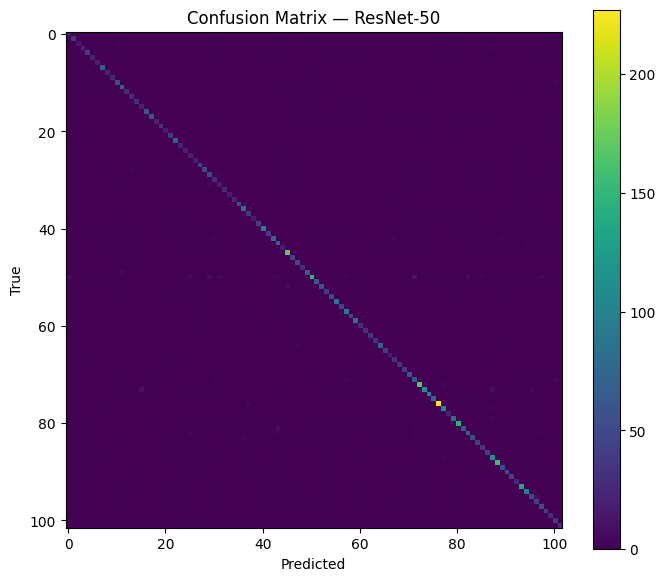

385/385 ━━━━━━━━━━━━━━━━━━━━ 93s 232ms/step
ViT-B16:  accuracy = 0.9883   macro-F1 = 0.9875


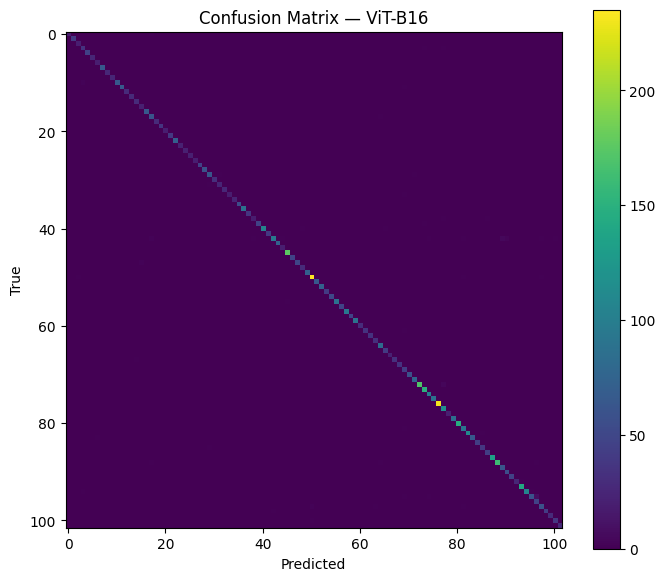


SUMMARY:  ResNet-50 acc=0.9089 F1=0.9060  |  ViT-B16 acc=0.9883 F1=0.9875


In [ ]:
# Cell 5 — Evaluate on the test set (RQ1)
def evaluate(clf, name):
    y_true = np.concatenate([y.numpy() for _, y in test_ds])
    y_pred = clf.predict(test_ds).argmax(1)
    acc = accuracy_score(y_true, y_pred); f1 = f1_score(y_true, y_pred, average="macro")
    print(f"{name}:  accuracy = {acc:.4f}   macro-F1 = {f1:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,7)); plt.imshow(cm, cmap="viridis")
    plt.title(f"Confusion Matrix — {name}"); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.colorbar(); plt.savefig(f"confusion_{name}.png", dpi=150, bbox_inches="tight"); plt.show()
    return y_true, y_pred, acc, f1

r_true, r_pred, r_acc, r_f1 = evaluate(resnet, "ResNet-50")
v_true, v_pred, v_acc, v_f1 = evaluate(vit,    "ViT-B16")
print(f"\nSUMMARY:  ResNet-50 acc={r_acc:.4f} F1={r_f1:.4f}  |  ViT-B16 acc={v_acc:.4f} F1={v_f1:.4f}")

In [ ]:
# Cell 6 — Most-confused species pairs (for misclassification analysis)
def top_conf(y_true, y_pred, name, k=10):
    cm = confusion_matrix(y_true, y_pred).astype(float); np.fill_diagonal(cm, 0)
    idx = np.dstack(np.unravel_index(np.argsort(cm.ravel())[::-1][:k], cm.shape))[0]
    print(f"\nTop {k} confusions for {name} (true -> predicted):")
    for i, j in idx: print(f"   class {i:>3} -> {j:>3} : {int(cm[i,j])}")
top_conf(r_true, r_pred, "ResNet-50"); top_conf(v_true, v_pred, "ViT-B16")


Top 10 confusions for ResNet-50 (true -> predicted):
   class  50 ->  71 : 15
   class  50 ->   0 : 11
   class  73 ->  15 : 11
   class  81 ->  43 : 9
   class  50 ->  29 : 8
   class  73 ->  87 : 8
   class  50 ->  82 : 7
   class  50 ->  97 : 7
   class  52 ->  45 : 7
   class  95 ->  96 : 7

Top 10 confusions for ViT-B16 (true -> predicted):
   class  95 ->  96 : 9
   class  42 ->  89 : 5
   class  72 ->  77 : 4
   class  42 ->  90 : 3
   class  47 ->  15 : 2
   class  42 ->  17 : 2
   class  97 ->  50 : 2
   class  10 ->   3 : 2
   class  88 ->  64 : 1
   class  95 ->  74 : 1


## After Cell 5/6
Send me the **SUMMARY line** (the two accuracies + F1) and the **Cell 6 lists**. I'll write the Results chapter from them.
RQ2 (Grad-CAM + attention) comes next, once these numbers look healthy.


Got sample images for class 95 and class 96.


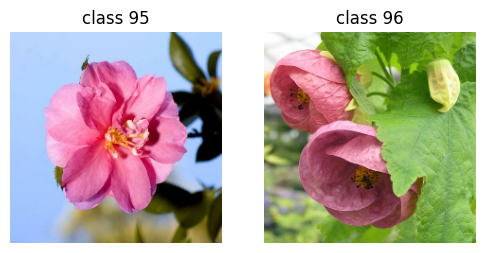

In [ ]:
# Cell 7 — grab sample images (focus on the confused pair: class 95 and 96)
import matplotlib.cm as cm

def get_image_of_class(target_cls):
    for x, y in test_ds.unbatch().batch(1):
        if int(y[0]) == target_cls:
            return x[0].numpy(), int(y[0])
    # fallback: any image
    for x, y in test_ds.take(1):
        return x[0].numpy(), int(y[0])

img95, _ = get_image_of_class(95)
img96, _ = get_image_of_class(96)
print("Got sample images for class 95 and class 96.")
plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(img95.astype("uint8")); plt.title("class 95"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(img96.astype("uint8")); plt.title("class 96"); plt.axis("off")
plt.show()

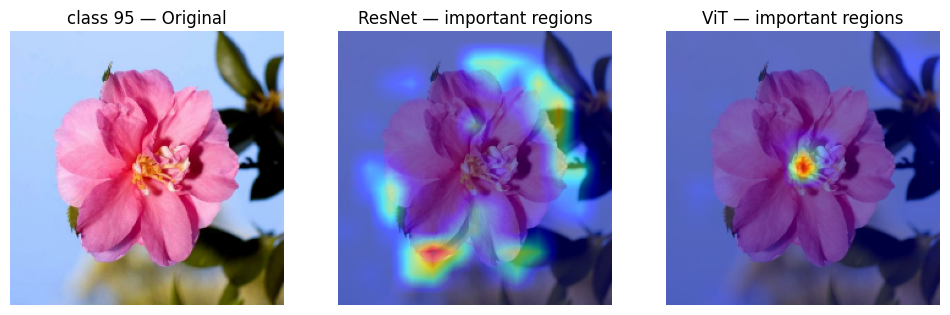

saved xai_class_95.png


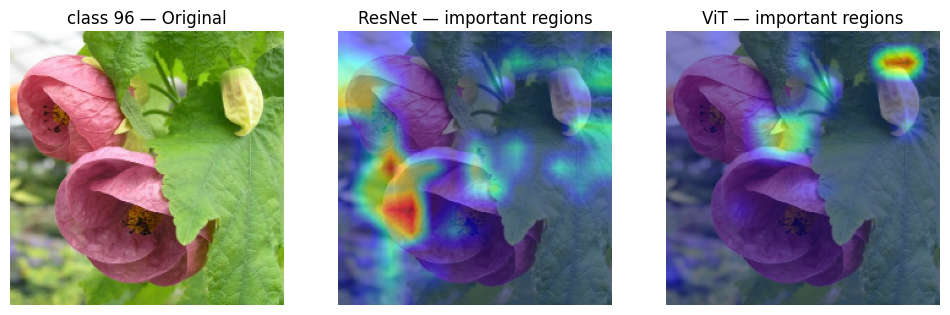

saved xai_class_96.png


In [ ]:
# Cell 8 (v3) — Occlusion sensitivity maps (robust: only uses model.predict)
def occlusion_map(model, img, patch=32, stride=16):
    x0 = img[None].astype("float32")
    true_cls = int(model.predict(x0, verbose=0).argmax(1)[0])
    base_conf = float(tf.nn.softmax(model.predict(x0, verbose=0)[0])[true_cls])
    H = W = IMG_SIZE
    heat = np.zeros(((H - patch)//stride + 1, (W - patch)//stride + 1), dtype="float32")
    batch, coords = [], []
    for a, i in enumerate(range(0, H - patch + 1, stride)):
        for b, j in enumerate(range(0, W - patch + 1, stride)):
            occ = img.copy(); occ[i:i+patch, j:j+patch, :] = 128.0
            batch.append(occ); coords.append((a, b))
    batch = np.array(batch, dtype="float32")
    probs = tf.nn.softmax(model.predict(batch, batch_size=64, verbose=0), axis=1).numpy()[:, true_cls]
    for (a, b), p in zip(coords, probs):
        heat[a, b] = base_conf - p          # drop in confidence = importance
    heat = np.maximum(heat, 0)
    heat = heat / (heat.max() + 1e-8)
    heat = tf.image.resize(heat[..., None], (H, W)).numpy()[..., 0]
    return heat

def show_row(img, title):
    g = occlusion_map(resnet, img)
    a = occlusion_map(vit, img)
    base = img/255.0
    fig, ax = plt.subplots(1, 3, figsize=(12,4))
    ax[0].imshow(img.astype("uint8")); ax[0].set_title(f"{title} — Original"); ax[0].axis("off")
    ax[1].imshow(base); ax[1].imshow(g, cmap="jet", alpha=0.5); ax[1].set_title("ResNet — important regions"); ax[1].axis("off")
    ax[2].imshow(base); ax[2].imshow(a, cmap="jet", alpha=0.5); ax[2].set_title("ViT — important regions"); ax[2].axis("off")
    fname = f"xai_{title.replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()
    print("saved", fname)

show_row(img95, "class 95")
show_row(img96, "class 96")

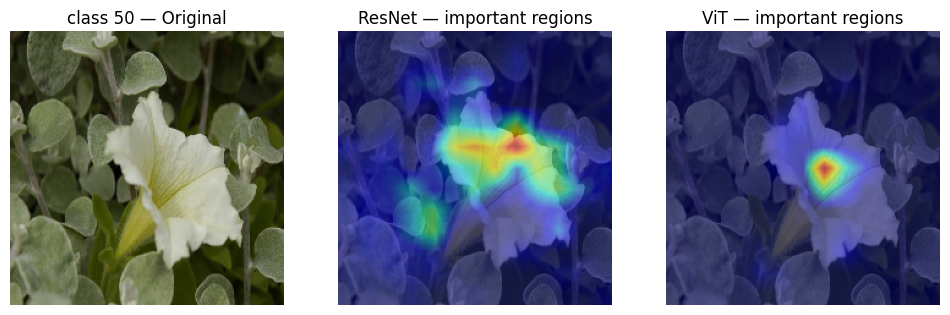

saved xai_class_50.png


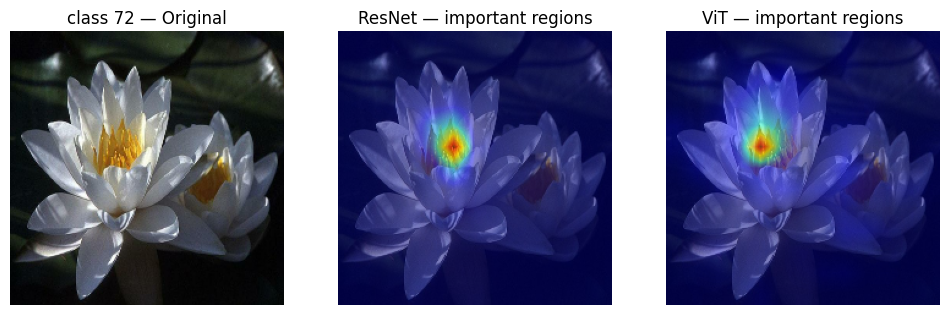

saved xai_class_72.png


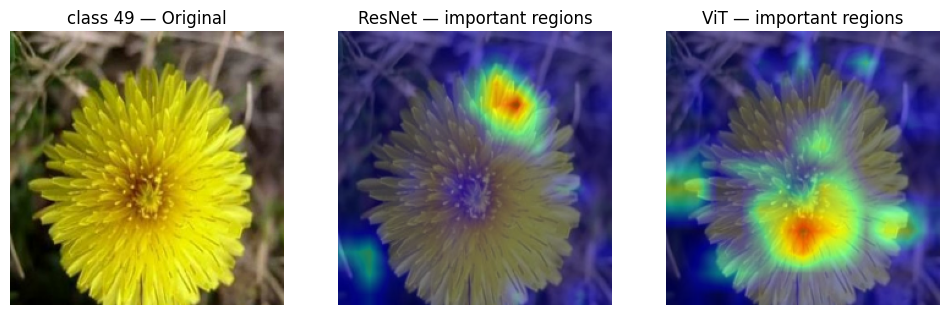

saved xai_class_49.png


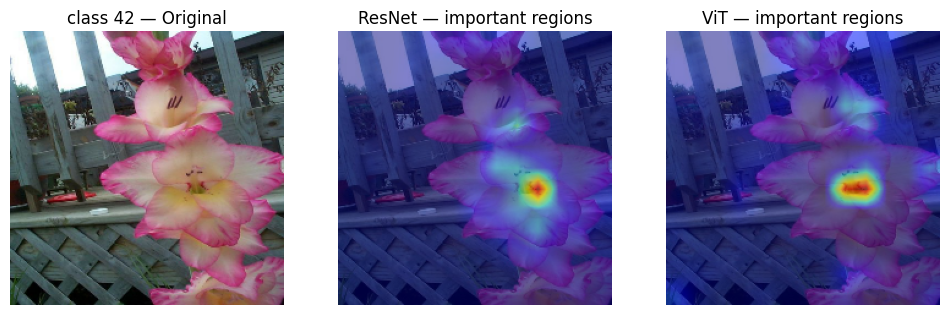

saved xai_class_42.png


In [ ]:
# Cell A — more occlusion maps on ResNet's characteristic error pairs
# (reuses occlusion_map + show_row from your earlier cell; models still in memory)

pairs_to_show = [50, 72, 49, 42]   # classes where ResNet struggled but ViT didn't

for c in pairs_to_show:
    img, _ = get_image_of_class(c)
    show_row(img, f"class {c}")

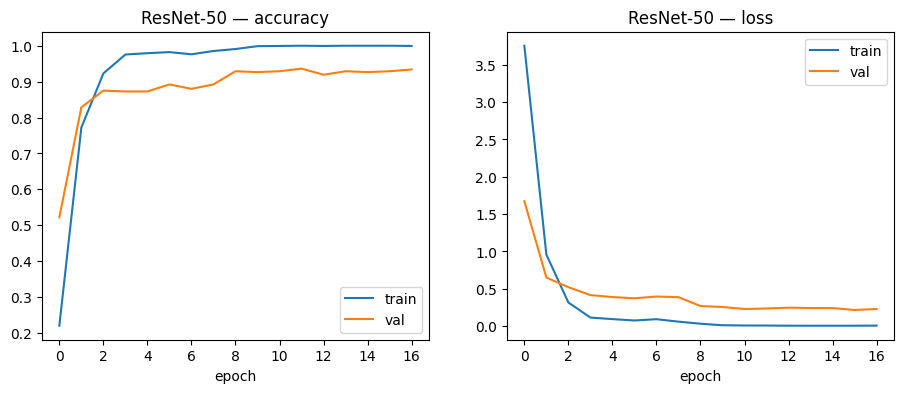

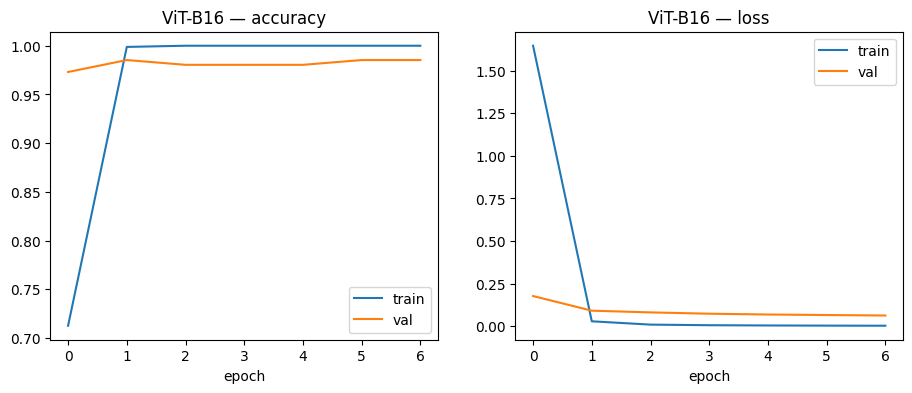

In [ ]:
# Cell B — training curves for both models (uses resnet_hist / vit_hist)
import matplotlib.pyplot as plt

def plot_history(hist, name):
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(h.get("accuracy", []), label="train")
    ax[0].plot(h.get("val_accuracy", []), label="val")
    ax[0].set_title(f"{name} — accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(h.get("loss", []), label="train")
    ax[1].plot(h.get("val_loss", []), label="val")
    ax[1].set_title(f"{name} — loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.savefig(f"curves_{name}.png", dpi=150, bbox_inches="tight"); plt.show()

plot_history(resnet_hist, "ResNet-50")
plot_history(vit_hist, "ViT-B16")